In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 1

##### 1.1 Download the dataset into your local computer. (ดาวนโหลด Dataset ที่แนบมา)
- อันนี้กดโหลดผ่าน google drive

##### 1.2 Read the dataset (.csv file) and then transform it into pandas Dataframe type. (นำเข้า csv file แปลง
เป็น dataframe)
- ทำการใช้ pandas แปลงเป็น dataframe

In [98]:
df = pd.read_csv("dataset.csv")
df.head()

,hours,sleep,score
0,3,5.0,27
1,14,NaN,85
2,14,5.0,82
3,8,NaN,49
4,10,4.0,59


##### 1.3 นักศึกษาที้เป็นรหัสนักศึกษาลงท้ายด้วย เลขคู่ ให้ใช้ข้อมูลตัÊงแต่แถว 11-51 อ้างอิงตามใน CSV
- slicing index 0-51

In [99]:
data = df[10:51]
data

,hours,sleep,score
10,9,5.0,57
11,13,8.0,86
12,4,9.0,44
13,6,8.0,51
14,15,7.0,93
15,11,5.0,67
16,9,5.0,57
17,15,7.0,93
18,1,7.0,23
19,1,5.0,17


#### 2

##### Show the first 7 rows and tail 7 rows. (แสดงผล Dataframe 7 แถวแรกและ 7 แถวหลัง)
- ใช้ head() กับ tail()

In [100]:
data.head(7)

,hours,sleep,score
10,9,5.0,57
11,13,8.0,86
12,4,9.0,44
13,6,8.0,51
14,15,7.0,93
15,11,5.0,67
16,9,5.0,57


In [101]:
data.tail(7)

,hours,sleep,score
43,10,4.0,59
44,10,6.0,65
45,1,8.0,26
46,7,NaN,44
47,9,NaN,60
48,3,4.0,24
49,6,9.0,54


##### 2.2 See data descripion. (แสดงผลคำบรรยายข้อมูล)
- น่าจะหมายถึง describe()

In [102]:
data.describe()

,hours,sleep,score
count,40.000000,38.000000,40.00000
mean,8.525000,6.552632,59.05000
std,4.408544,1.719481,23.32815
min,1.000000,4.000000,17.00000
25%,5.500000,5.000000,43.50000
50%,9.000000,7.000000,59.00000
75%,12.250000,8.000000,77.50000
max,15.000000,9.000000,99.00000


##### 2.3 Check for missing values.
ใช้ info() ในการดูว่ามี null เท่าไหร่

In [103]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 10 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hours   40 non-null     int64  
 1   sleep   38 non-null     float64
 2   score   40 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


##### 2.4 Plot histograms or boxplots or pair plots for all columns. (แสดงผลเป็น Histogram หรือ boxplot หรือ pair
plot)

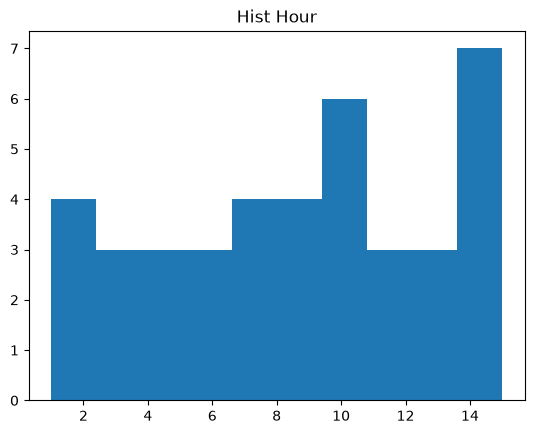

In [104]:
plt.title('Hist Hour')
plt.hist(data['hours'])
plt.show()

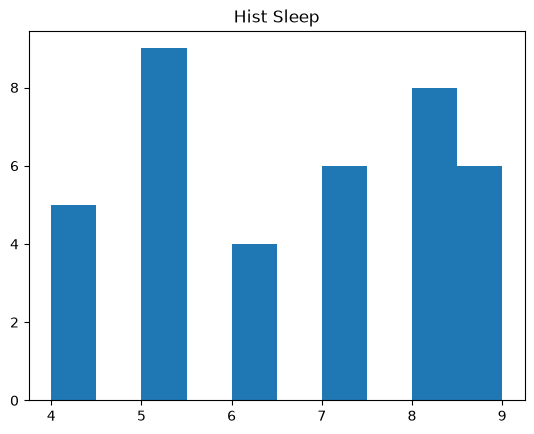

In [105]:
plt.title('Hist Sleep')
plt.hist(data['sleep'])
plt.show()

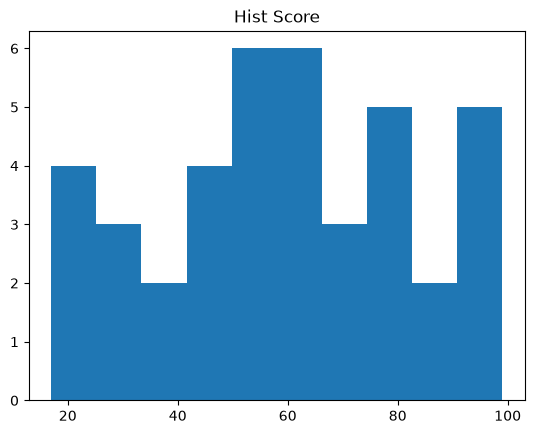

In [106]:
plt.title('Hist Score')
plt.hist(data['score'])
plt.show()

##### 2.5 Compute the correlaƟon matrix (Using “Pearson” method). (คำนวณ correlation ของข้อมูลโดยใช้วิธี
Pearson)
- ใช้ .corr(method='pearson')

In [107]:
data.corr(method='pearson')

,hours,sleep,score
hours,1.000000,0.130084,0.975583
sleep,0.130084,1.000000,0.339956
score,0.975583,0.339956,1.000000


#### 3

##### 3.1 Impute missing values with Median. (เติมข่อมูลที่หายไปด้วยการตรวจสอบมัธยฐาน)
- fill ด้วย median()

In [108]:
data['sleep'] = data['sleep'].fillna(data['sleep'].median())

In [109]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 10 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hours   40 non-null     int64  
 1   sleep   40 non-null     float64
 2   score   40 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


##### 3.2 Create a new column “hours_squared” = hours ** 2 (สร้างคอลัมน้ใหม่แบบ numerical)

In [110]:
data['hours_squared'] = data['hours'] ** 2
data.head()

,hours,sleep,score,hours_squared
10,9,5.0,57,81
11,13,8.0,86,169
12,4,9.0,44,16
13,6,8.0,51,36
14,15,7.0,93,225


##### 3.3 Create a new column “sleep_quality” = low/normal/high categories (สร่างคอลัมน์ใหม่แบบ categorical/binning 3 ช่วง/ประเภท)

In [111]:
data['sleep_quality'] = pd.cut(
	data['hours'], 
	bins=[0, 5, 7, np.inf], 
	labels=['low', 'normal', 'high'], 
	right=False
)
data.head()

,hours,sleep,score,hours_squared,sleep_quality
10,9,5.0,57,81,high
11,13,8.0,86,169,high
12,4,9.0,44,16,low
13,6,8.0,51,36,normal
14,15,7.0,93,225,high


##### 3.4 Create a new column “efficiency” = hours / sleep. (สร้างคอลัมน์ใหม่จากการปฏิสัมพันธ์ 2 ฟีเจอร์)

In [112]:
data['efficiency'] = data['hours'] / data['sleep']
data.head()

,hours,sleep,score,hours_squared,sleep_quality,efficiency
10,9,5.0,57,81,high,1.800000
11,13,8.0,86,169,high,1.625000
12,4,9.0,44,16,low,0.444444
13,6,8.0,51,36,normal,0.750000
14,15,7.0,93,225,high,2.142857


#### 4

##### 4.1 Scatter plot: sleep vs score (i.e., x-axis is sleep, y-axis is score). (แสดงผลเป็น Scatter plot 2 มิติ)

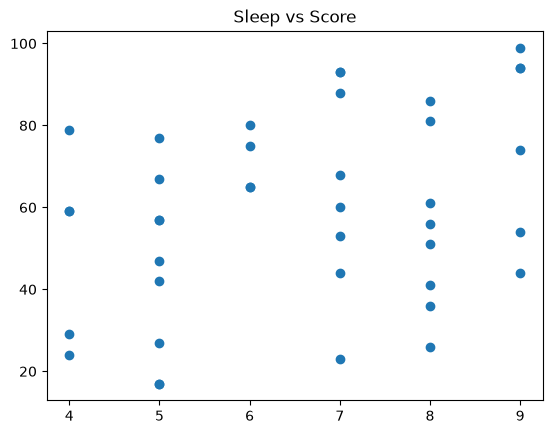

In [113]:
plt.title("Sleep vs Score")
plt.scatter(data['sleep'], data['score'])
plt.show()

#### 5

##### 5.1 Display the data frame first 10 rows and tail 10 rows with new features. (แสดงผล Dataframe 10 แถวแรกและ 10 แถวหลังที่มีฟีเจอร์ใหม่)
- head กับ tail 10 แถว

In [114]:
data.head(10)

,hours,sleep,score,hours_squared,sleep_quality,efficiency
10,9,5.0,57,81,high,1.800000
11,13,8.0,86,169,high,1.625000
12,4,9.0,44,16,low,0.444444
13,6,8.0,51,36,normal,0.750000
14,15,7.0,93,225,high,2.142857
15,11,5.0,67,121,high,2.200000
16,9,5.0,57,81,high,1.800000
17,15,7.0,93,225,high,2.142857
18,1,7.0,23,1,low,0.142857
19,1,5.0,17,1,low,0.200000


In [115]:
data.tail(10)

,hours,sleep,score,hours_squared,sleep_quality,efficiency
40,1,5.0,17,1,low,0.200000
41,10,9.0,74,100,high,1.111111
42,14,7.0,88,196,high,2.000000
43,10,4.0,59,100,high,2.500000
44,10,6.0,65,100,high,1.666667
45,1,8.0,26,1,low,0.125000
46,7,7.0,44,49,high,1.000000
47,9,7.0,60,81,high,1.285714
48,3,4.0,24,9,low,0.750000
49,6,9.0,54,36,normal,0.666667


##### 5.2 Print correlation with score with new and existing features.

In [116]:
data.corr(numeric_only=True)

,hours,sleep,score,hours_squared,efficiency
hours,1.000000,0.128009,0.975583,0.969865,0.842241
sleep,0.128009,1.000000,0.333369,0.148279,-0.357170
score,0.975583,0.333369,1.000000,0.954642,0.723740
hours_squared,0.969865,0.148279,0.954642,1.000000,0.790666
efficiency,0.842241,-0.357170,0.723740,0.790666,1.000000
